In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Loading Required packages

In [3]:
###1. Loading Required packages
import warnings
warnings.filterwarnings("ignore")
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Load the Fashion MNIST dataset

In [4]:
fashion_mnist = tf.keras.datasets.fashion_mnist

- (train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()


# Data Dividing

In [7]:
# splitting the data into test and train set
(X_train, Y_train), (X_test, Y_test) = fashion_mnist.load_data()

In [8]:
X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [9]:
Y_train

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [10]:
X_test

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [11]:
Y_test

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

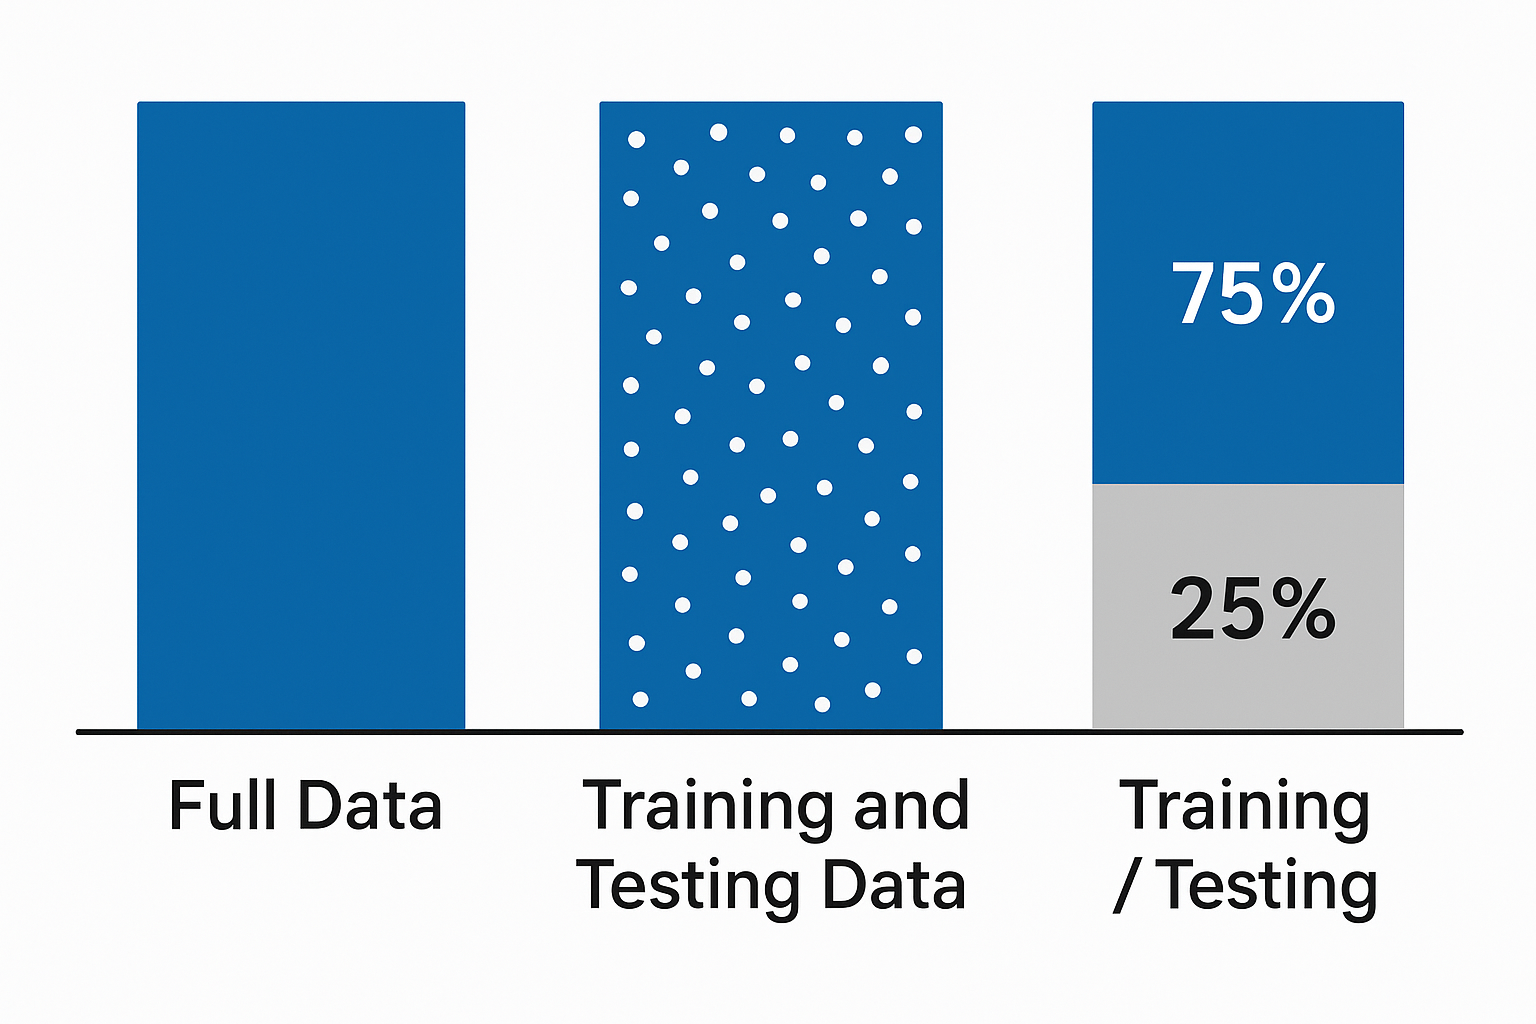

# Visualizing Sample Images from the Test Dataset

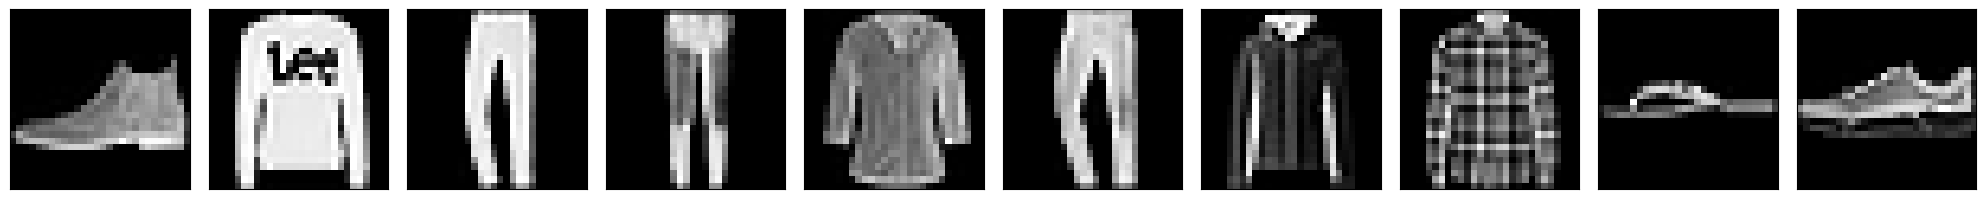

In [12]:
import matplotlib.pyplot as plt

# Define how many images you want to visualize
num_samples = 10

# Set up the canvas for plotting
plt.figure(figsize=(20, 4))

# Iterate through the first 'num_samples' test images
for idx in range(num_samples):
    # Create subplot for each image
    subplot = plt.subplot(2, num_samples, idx + 1)

    # Render the grayscale image (28x28 pixels)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')

    # Remove axis ticks for a cleaner look
    subplot.set_xticks([])
    subplot.set_yticks([])

# Display all images in one figure
plt.tight_layout()
plt.show()
plt.close()


# Flattening Image Data for Model Input

In [13]:
# Display the original shape of training data and labels
print(f"Original X_train shape: {X_train.shape}")
print(f"Original Y_train shape: {Y_train.shape}")

# Flatten each 28x28 image into a 784-dimensional vector
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

# Optional: print the new shape to confirm
print(f"Flattened X_train shape: {X_train.shape}")
print(f"Flattened X_test shape: {X_test.shape}")


Original X_train shape: (60000, 28, 28)
Original Y_train shape: (60000,)
Flattened X_train shape: (60000, 784)
Flattened X_test shape: (10000, 784)


# Normalizing Pixel Intensities with Min-Max Scaling

In [14]:
# Convert pixel values to float for precision during normalization
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

# Scale pixel values to the range [0, 1]
# (0 represents black; 1 represents white)
X_train /= 255.0
X_test /= 255.0

 # One-Hot Encoding Target Labels for Classification

In [15]:
from tensorflow.keras.utils import to_categorical

# Define the number of distinct classes in the dataset
num_classes = 10

# Transform class labels into one-hot encoded vectors
Y_train = to_categorical(Y_train, num_classes)
Y_test = to_categorical(Y_test, num_classes)

# Display the updated shapes of feature and label arrays
print(f"Processed X_train shape: {X_train.shape}")
print(f"Processed Y_train shape: {Y_train.shape}")

Processed X_train shape: (60000, 784)
Processed Y_train shape: (60000, 10)


# Defining Model Architecture and Training Hyperparameters

In [16]:
# Input dimension (flattened 28x28 image)
input_size = 784

# Number of output classes (digits 0–9)
num_classes = 10

# Training configuration
batch_size = 250       # Number of samples per gradient update
epochs = 90            # Total passes through the full training set

# Hidden layer configuration (deep feedforward structure)
hidden1 = 700
hidden2 = 600
hidden3 = 500
hidden4 = 420
hidden5 = 380
hidden6 = 250
hidden7 = 200
hidden8 = 150
hidden9 = 100
hidden10 = 90
hidden11 = 60
hidden12 = 10  

# Enhanced ANN with Dropout, Callbacks, and Regularization
## Add Dropout to Reduce Overfitting

In [17]:
from tensorflow.keras.layers import Dropout

model = Sequential()
model.add(Dense(hidden1, input_dim=input_size, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(hidden2, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(hidden3, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(hidden4, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(hidden5, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(hidden6, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(hidden7, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(hidden8, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(hidden9, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(hidden10, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(hidden11, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(hidden12, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(num_classes, activation='softmax'))


I0000 00:00:1751277708.190472      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1751277708.191176      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## Add Callbacks (EarlyStopping, ModelCheckpoint, ReduceLROnPlateau)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Stop training early if validation loss doesn't improve
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Save the best model to a file
checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True, monitor='val_loss')

# Reduce learning rate when a metric has stopped improving
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, verbose=1)

### Compile with Better Optimizer

In [19]:
from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 700)                 │         549,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 700)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 600)                 │         420,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 600)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 500)                 │         300,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 500)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 420)                 │         210,420 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 420)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 380)                 │         159,980 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 380)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 250)                 │          95,250 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 250)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 200)                 │          50,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 150)                 │          30,150 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 100)                 │          15,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 90)                  │           9,090 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 90)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 60)                  │           5,460 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 5,540,912 (21.14 MB)

 Trainable params: 1,846,970 (7.05 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,693,942 (14.09 MB)

## Train the Model with Validation Split & Callbacks

In [20]:
history = model.fit(X_train, Y_train,
                    validation_split=0.2,
                    epochs=epochs,
                    batch_size=batch_size,
                    callbacks=[early_stop, checkpoint, reduce_lr],
                    verbose=1)


Epoch 1/90


I0000 00:00:1751277804.561363     128 service.cc:148] XLA service 0x787fd8019ff0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1751277804.562333     128 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1751277804.562351     128 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1751277805.237675     128 cuda_dnn.cc:529] Loaded cuDNN version 90300


 30/192 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1057 - loss: 2.3054

I0000 00:00:1751277812.165553     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


192/192 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.1535 - loss: 2.2139 - val_accuracy: 0.2195 - val_loss: 2.0141 - learning_rate: 0.0010
Epoch 2/90
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2410 - loss: 1.9808 - val_accuracy: 0.3156 - val_loss: 1.6727 - learning_rate: 0.0010
Epoch 3/90
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3249 - loss: 1.7045 - val_accuracy: 0.3830 - val_loss: 1.4375 - learning_rate: 0.0010
Epoch 4/90
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3878 - loss: 1.4714 - val_accuracy: 0.5724 - val_loss: 1.1872 - learning_rate: 0.0010
Epoch 5/90
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4660 - loss: 1.2689 - val_accuracy: 0.6733 - val_loss: 1.0009 - learning_rate: 0.0010
Epoch 6/90
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5327 - loss: 1.1769 - val_accuracy: 0.7144 - val_loss: 0.8861 - learning_rate: 0.0010
Epoch 7/90
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5721 - loss: 1.1252 - val_accur

# Visualize Training Progress

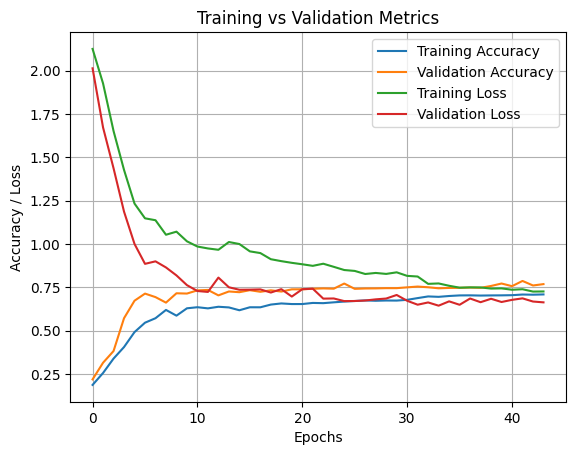

In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Metrics")
plt.xlabel("Epochs")
plt.ylabel("Accuracy / Loss")
plt.grid(True)
plt.show()


In [23]:
# Evaluate on training data
train_loss, train_accuracy = model.evaluate(X_train, Y_train, verbose=0)

# Evaluate on test data
test_loss, test_accuracy = model.evaluate(X_test, Y_test, verbose=0)

print("\n Performance Summary:")
print(" Training Accuracy: {:.4f}".format(train_accuracy))
print(" Testing Accuracy : {:.4f}".format(test_accuracy))

# Check for overfitting condition
diff = train_accuracy - test_accuracy
if diff > 0.05:
    print("\n Potential Overfitting Detected (Accuracy Gap: {:.4f})".format(diff))
else:
    print("\n Model appears well-generalized.")



 Performance Summary:
 Training Accuracy: 0.7539
 Testing Accuracy : 0.7438

 Model appears well-generalized.


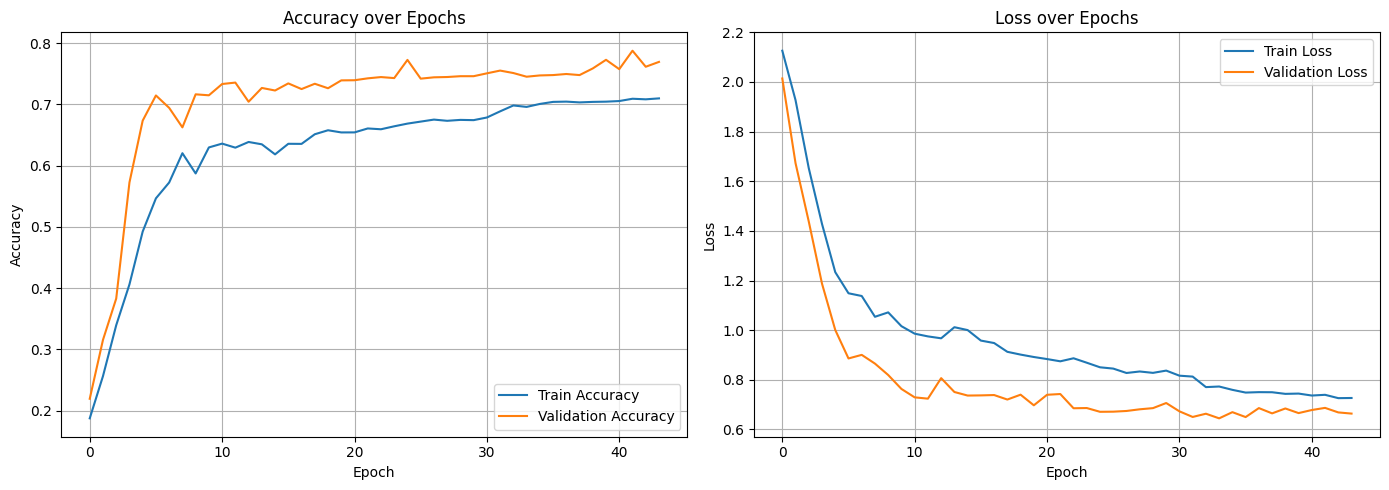

In [25]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# Enhanced ANN Model

In [27]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping
from keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# Define model architecture
model = Sequential()

# Input + First Hidden Layer
model.add(Dense(hidden1, input_dim=input_size, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Second Hidden Layer
model.add(Dense(hidden2, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Third Hidden Layer
model.add(Dense(hidden3, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Fourth Hidden Layer
model.add(Dense(hidden4, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Fifth Hidden Layer
model.add(Dense(hidden5, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Sixth Hidden Layer
model.add(Dense(hidden6, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Seventh Hidden Layer
model.add(Dense(hidden7, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Eighth Hidden Layer
model.add(Dense(hidden8, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Ninth Hidden Layer
model.add(Dense(hidden9, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Tenth Hidden Layer
model.add(Dense(hidden10, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Eleventh Hidden Layer
model.add(Dense(hidden11, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Twelfth Hidden Layer
model.add(Dense(hidden12, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Output Layer
model.add(Dense(num_classes, activation='softmax'))

# Compile model with Adam optimizer
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Define EarlyStopping to stop training when validation accuracy stops improving
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

# Train the model with validation split
history = model.fit(
    X_train, Y_train,
    validation_split=0.2,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=1
)

# Show model summary
model.summary()


Epoch 1/90
192/192 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.1777 - loss: 2.3674 - val_accuracy: 0.6050 - val_loss: 1.1937
Epoch 2/90
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4918 - loss: 1.3690 - val_accuracy: 0.7053 - val_loss: 0.8581
Epoch 3/90
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6427 - loss: 1.0220 - val_accuracy: 0.7931 - val_loss: 0.6635
Epoch 4/90
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7221 - loss: 0.8272 - val_accuracy: 0.8026 - val_loss: 0.5893
Epoch 5/90
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7666 - loss: 0.7208 - val_accuracy: 0.8121 - val_loss: 0.5312
Epoch 6/90
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7865 - loss: 0.6700 - val_accuracy: 0.8233 - val_loss: 0.5675
Epoch 7/90
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7992 - loss: 0.6371 - val_accuracy: 0.8278 - val_loss: 0.5624
Epoch 8/90
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8130 - loss: 0.6071 - val_accuracy: 

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                     │ (None, 700)                 │         549,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 700)                 │           2,800 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_24 (Dropout)                 │ (None, 700)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 600)                 │         420,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 600)                 │           2,400 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_25 (Dropout)                 │ (None, 600)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 500)                 │         300,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 500)                 │           2,000 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_26 (Dropout)                 │ (None, 500)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 420)                 │         210,420 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ (None, 420)                 │           1,680 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_27 (Dropout)                 │ (None, 420)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 380)                 │         159,980 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_16               │ (None, 380)                 │           1,520 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_28 (Dropout)                 │ (None, 380)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 250)                 │          95,250 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_17               │ (None, 250)                 │           1,000 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_29 (Dropout)                 │ (None, 250)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 5,568,592 (21.24 MB)

 Trainable params: 1,853,890 (7.07 MB)

 Non-trainable params: 6,920 (27.03 KB)

 Optimizer params: 3,707,782 (14.14 MB)

# Plot Training vs Validation Accuracy & Loss

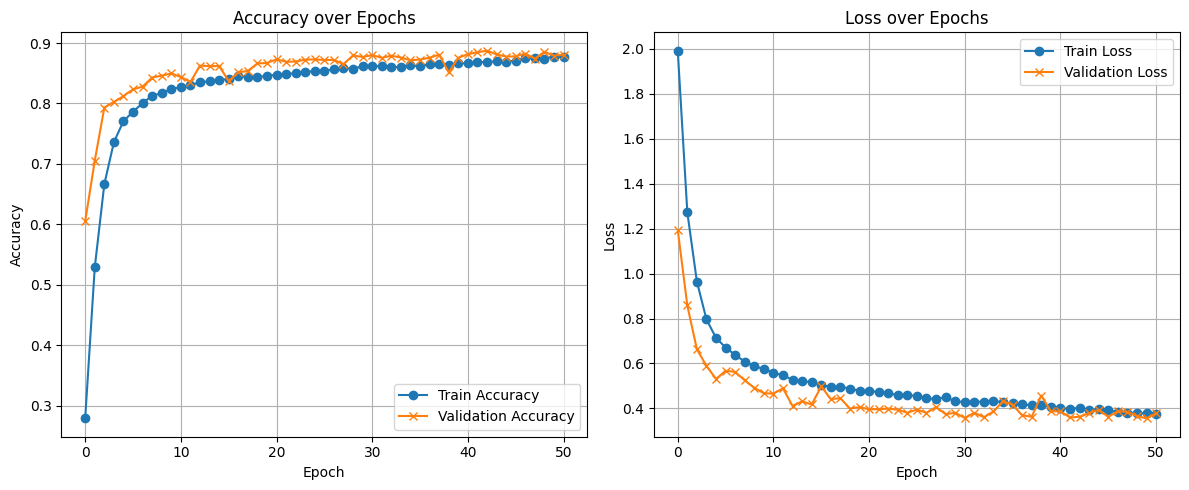

In [28]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# Evaluate on Test Set


 Test Accuracy: 0.8755

 Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.86      0.83      1000
           1       0.99      0.97      0.98      1000
           2       0.82      0.76      0.79      1000
           3       0.89      0.88      0.88      1000
           4       0.74      0.84      0.78      1000
           5       0.98      0.96      0.97      1000
           6       0.68      0.62      0.65      1000
           7       0.93      0.97      0.95      1000
           8       0.98      0.97      0.97      1000
           9       0.96      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



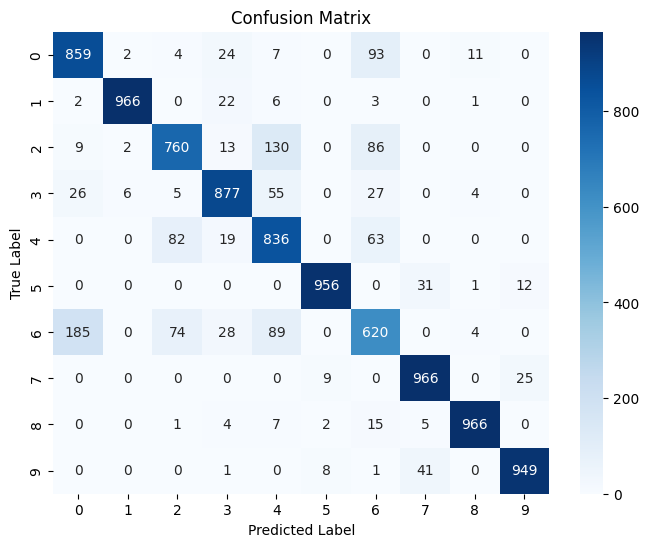

In [30]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import numpy as np

# Predict probabilities and class labels
y_pred_probs = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(Y_test, axis=1)

# Accuracy Score
test_acc = accuracy_score(y_true, y_pred_classes)
print(f"\n Test Accuracy: {test_acc:.4f}")

# Classification Report
print("\n Classification Report:")
print(classification_report(y_true, y_pred_classes))

# Confusion Matrix
conf_mat = confusion_matrix(y_true, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


# Detect Overfitting/Underfitting

In [31]:
def detect_overfit_underfit(history, threshold=0.05):
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    train_loss = history.history['loss'][-1]
    val_loss = history.history['val_loss'][-1]

    print(f"Training Accuracy:  {train_acc:.4f}")
    print(f"Validation Accuracy:{val_acc:.4f}")
    print(f"Training Loss:     {train_loss:.4f}")
    print(f"Validation Loss:   {val_loss:.4f}")

    acc_diff = train_acc - val_acc
    loss_diff = val_loss - train_loss

    print("\nModel Diagnosis:")
    if acc_diff > threshold and loss_diff > threshold:
        print(" Overfitting detected: High training accuracy, but much lower validation accuracy.")
    elif train_acc < 0.6 and val_acc < 0.6:
        print(" Underfitting detected: Both training and validation accuracy are low.")
    elif abs(acc_diff) <= threshold:
        print(" Model is likely well-generalized.")
    else:
        print(" Check further – mixed signs. Consider tuning or adding regularization.")


In [32]:
detect_overfit_underfit(history)


Training Accuracy:  0.8761
Validation Accuracy:0.8808
Training Loss:     0.3745
Validation Loss:   0.3785

Model Diagnosis:
 Model is likely well-generalized.


# Visualizing Model Predictions (Multi-Class)

In [33]:
import numpy as np

# Select a subset of samples (0 to 19) from the test set for visualization
X_valid = X_test[0:20]
actual_labels = Y_test[0:20]

# Predict class probabilities for the selected samples
y_pred_probs_valid = model.predict(X_valid)

# Get the predicted class (index of highest probability)
y_pred_valid = np.argmax(y_pred_probs_valid, axis=1)

# Convert one-hot encoded true labels back to class indices
true_labels = np.argmax(actual_labels, axis=1)

# Display predicted vs actual labels
for i in range(len(y_pred_valid)):
    print(f"Sample {i+1} — Predicted: {y_pred_valid[i]} | Actual: {true_labels[i]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 842ms/step
Sample 1 — Predicted: 9 | Actual: 9
Sample 2 — Predicted: 2 | Actual: 2
Sample 3 — Predicted: 1 | Actual: 1
Sample 4 — Predicted: 1 | Actual: 1
Sample 5 — Predicted: 6 | Actual: 6
Sample 6 — Predicted: 1 | Actual: 1
Sample 7 — Predicted: 4 | Actual: 4
Sample 8 — Predicted: 6 | Actual: 6
Sample 9 — Predicted: 5 | Actual: 5
Sample 10 — Predicted: 7 | Actual: 7
Sample 11 — Predicted: 4 | Actual: 4
Sample 12 — Predicted: 5 | Actual: 5
Sample 13 — Predicted: 5 | Actual: 7
Sample 14 — Predicted: 3 | Actual: 3
Sample 15 — Predicted: 4 | Actual: 4
Sample 16 — Predicted: 1 | Actual: 1
Sample 17 — Predicted: 2 | Actual: 2
Sample 18 — Predicted: 2 | Actual: 4
Sample 19 — Predicted: 8 | Actual: 8
Sample 20 — Predicted: 0 | Actual: 0


# Show Image, Predicted Label & True Label

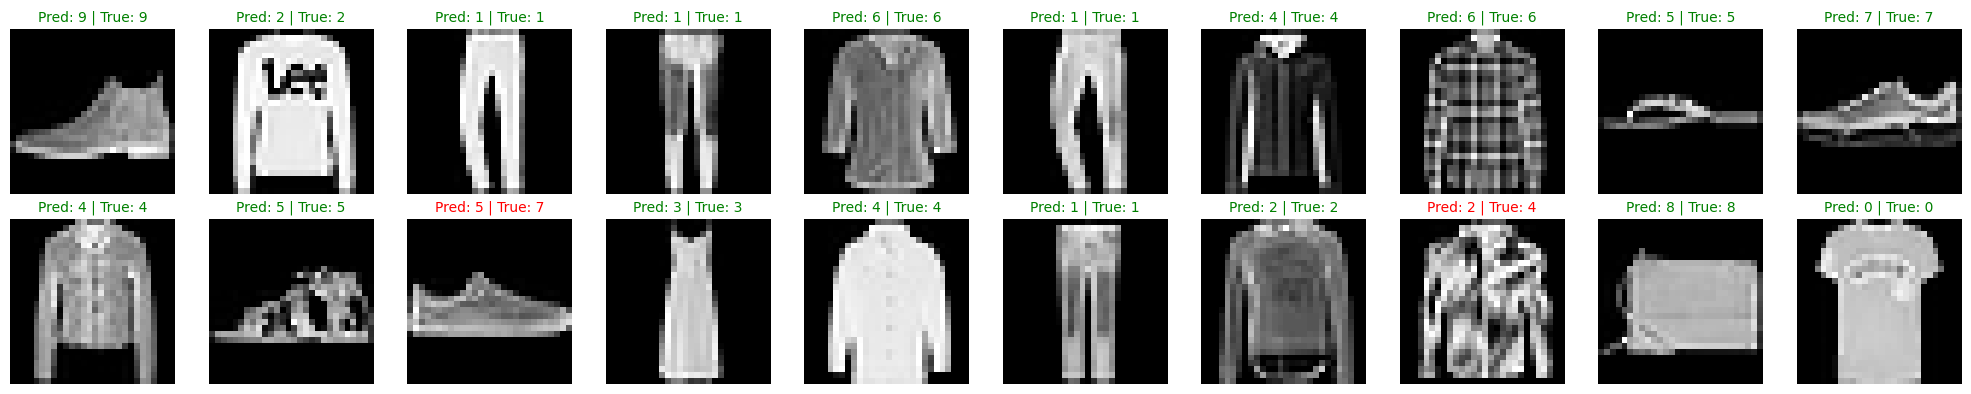

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Total images to show
n = len(X_valid)

# Get true class labels from one-hot encoded Y_test
true_labels = np.argmax(actual_labels, axis=1)
predicted_labels = np.argmax(y_pred_probs_valid, axis=1)

# Set up the figure
plt.figure(figsize=(20, 4))

for i in range(n):
    ax = plt.subplot(2, n//2, i + 1)
    
    # Show the image
    plt.imshow(X_valid[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    
    # Show predicted vs actual
    pred = predicted_labels[i]
    true = true_labels[i]
    
    title_color = 'green' if pred == true else 'red'
    ax.set_title(f"Pred: {pred} | True: {true}", color=title_color, fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()


# Save Model in `.keras` Format


In [35]:
# Save the trained model in .keras format
model.save("Fashion-Mnist.keras")
print("Model successfully saved as 'Fashion-Mnist.keras'")


Model successfully saved as 'Fashion-Mnist.keras'


# Load the Model Later

In [36]:
from keras.models import load_model

# Load the saved model
loaded_model = load_model("Fashion-Mnist.keras")
print("Model loaded successfully!")


Model loaded successfully!


# Use the Loaded Model for Predictions

In [37]:
import numpy as np

# Predict probabilities for test samples
y_pred_probs = model.predict(X_test[:10])  # shape: (10, 10)

# Get predicted classes (digit labels)
predicted_classes = np.argmax(y_pred_probs, axis=1)

print("Predicted digit labels:", predicted_classes)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 839ms/step
Predicted digit labels: [9 2 1 1 6 1 4 6 5 7]


# Compare with Actual Labels

In [38]:
# If Y_test is one-hot encoded
true_classes = np.argmax(Y_test[:10], axis=1)

print("Actual digit labels   :", true_classes)


Actual digit labels   : [9 2 1 1 6 1 4 6 5 7]


# Visualize Prediction Results 

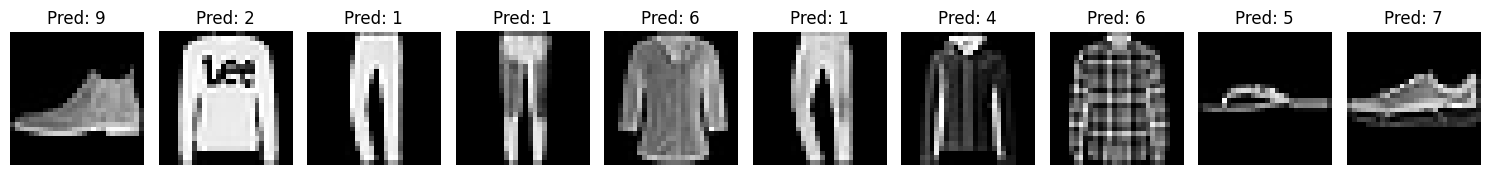

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 3))
for i in range(10):
    ax = plt.subplot(1, 10, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {predicted_classes[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [40]:
# For Fashion MNIST labels
label_map = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}


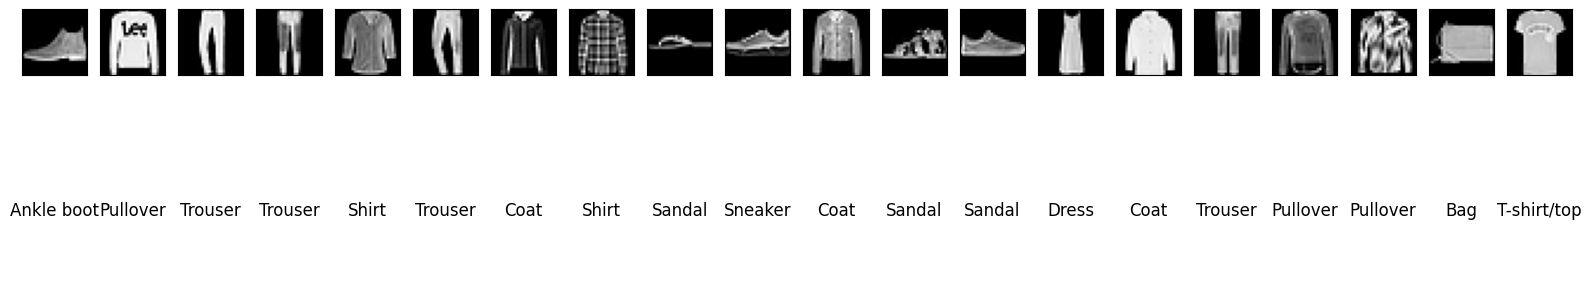

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Mapping from digit to label (update this based on your dataset)
label_map = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

# Number of images to visualize
n = len(X_valid)

plt.figure(figsize=(20, 4))

for i in range(n):
    # Display the original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_valid[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Predict the class label
    predicted_class = np.argmax(y_pred_probs_valid[i])
    predicted_label = label_map[predicted_class]

    # Show label instead of just digit
    ax = plt.subplot(2, n, i + 1 + n)
    plt.text(0.5, 0.5, predicted_label, fontsize=12, ha='center', va='center')
    plt.axis('off')

plt.show()
plt.close()
